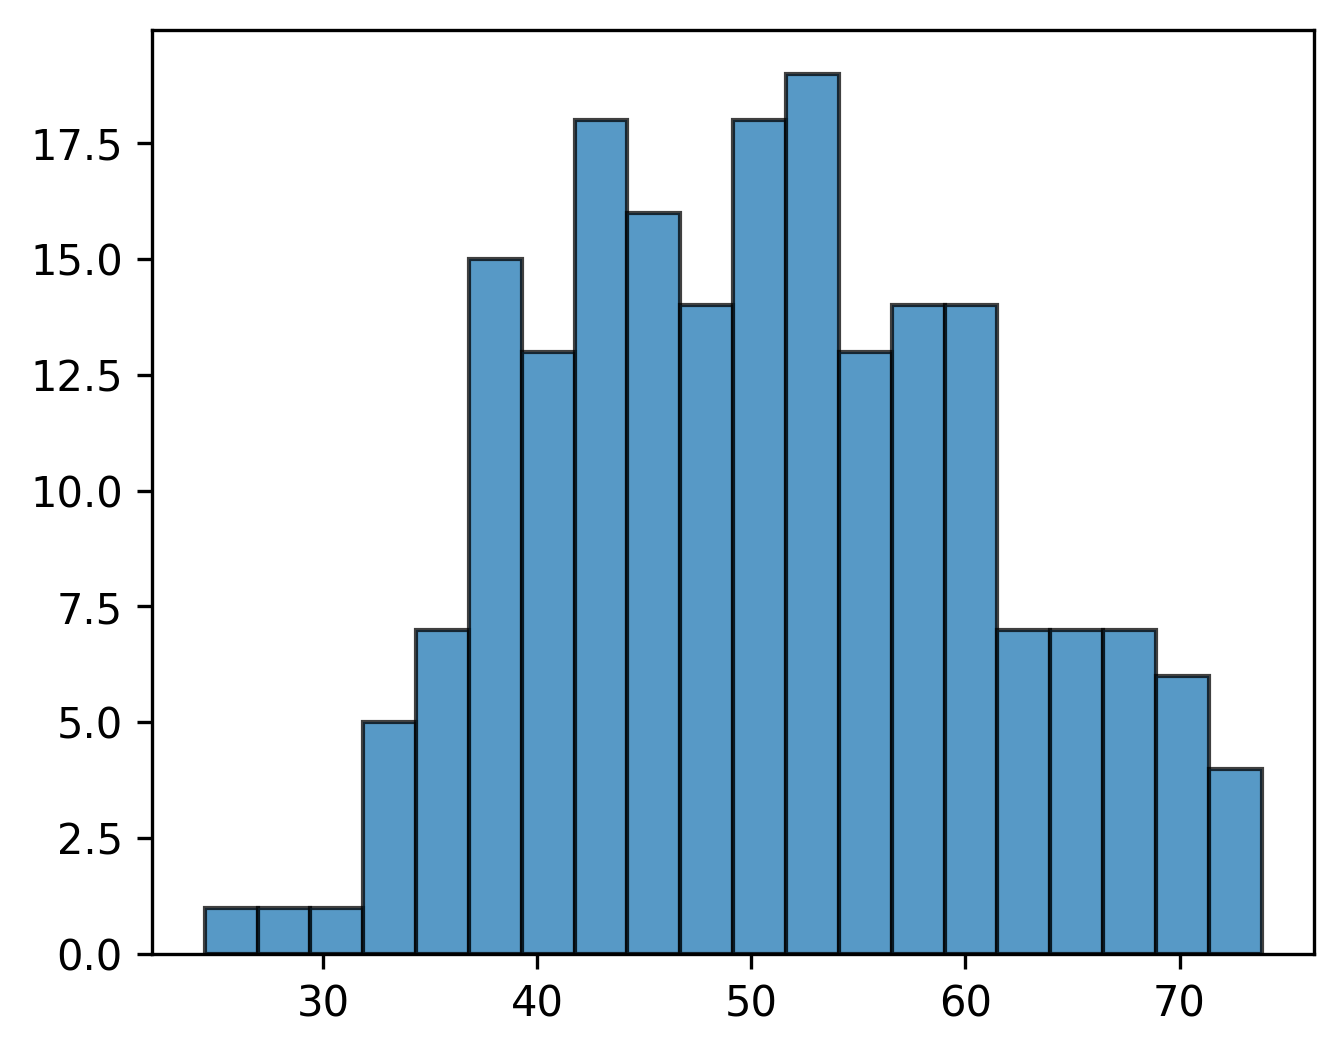

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 假設你的資料 data
np.random.seed(0)
data = np.random.normal(loc=50, scale=10, size=200)

plt.figure(figsize=(5, 4), dpi=300) # 適合論文解析度

plt.hist(
    data, 
    bins=20, 
    edgecolor='black', 
    linewidth=1.0, 
    alpha=0.75
)

#plt.xlabel("Value", fontsize=12)
#plt.ylabel("Frequency", fontsize=12)
#plt.title("Histogram Example", fontsize=14)

#plt.tight_layout()
#plt.savefig("histogram_example.png")  # 若要存檔
plt.show()

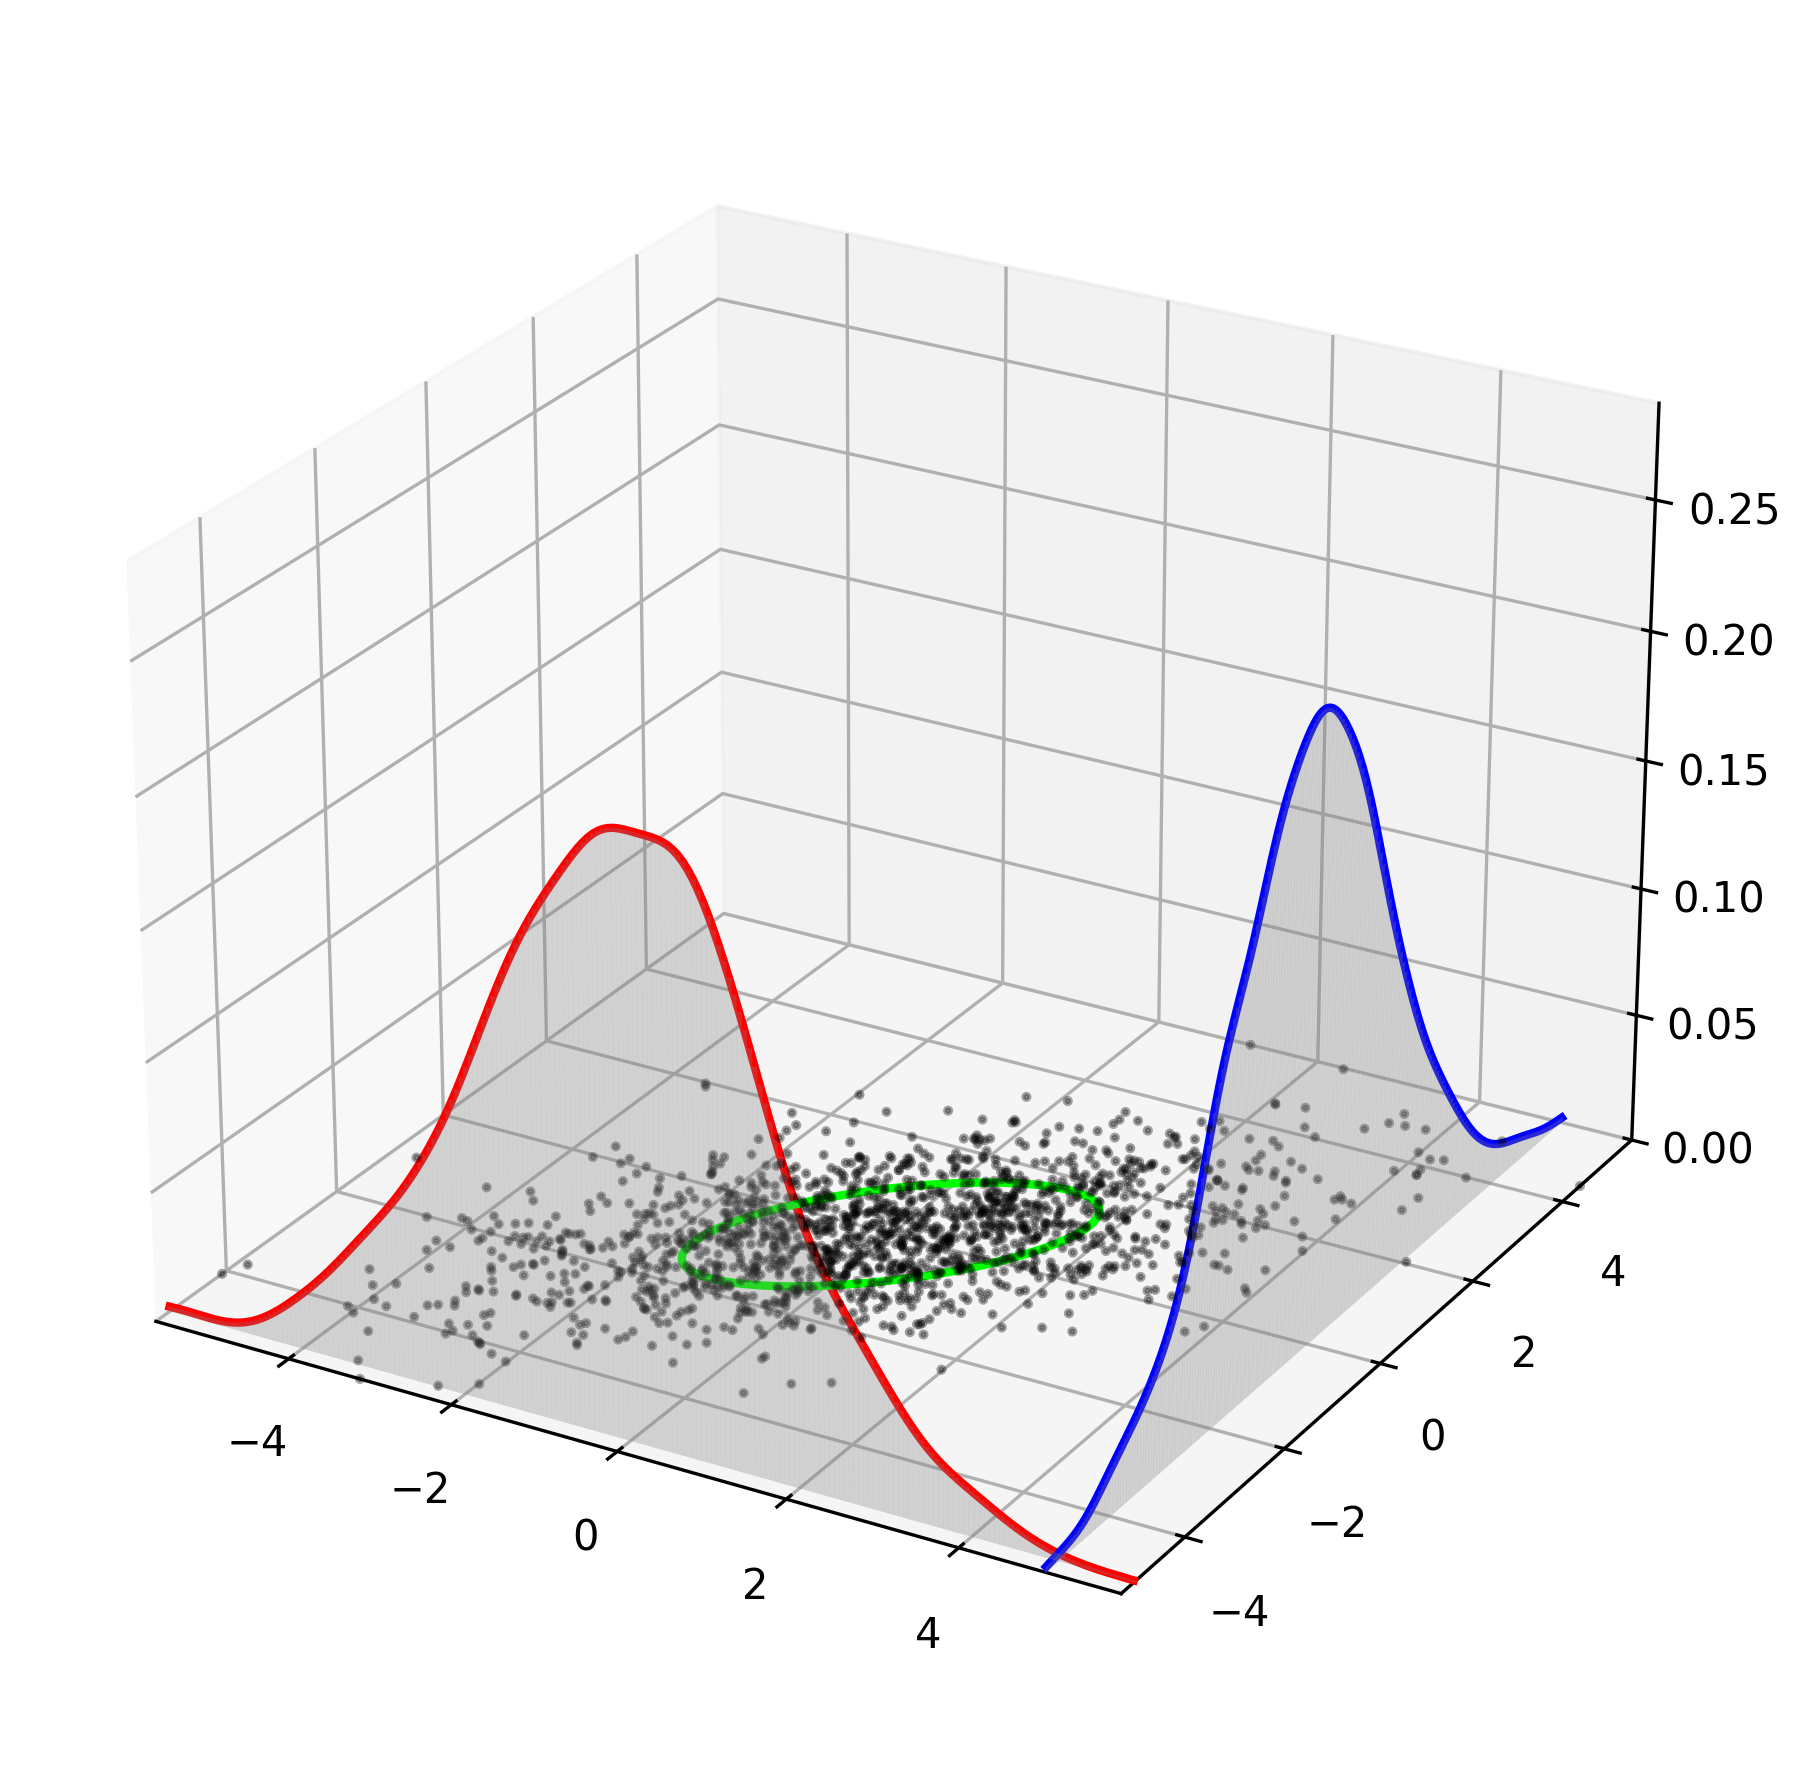

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal, gaussian_kde

np.random.seed(42)

# Generate correlated bivariate Gaussian data
mean = [0, 0]
cov = [[3, 2],
       [2, 3]]
data = np.random.multivariate_normal(mean, cov, 1500)
x = data[:, 0]
y = data[:, 1]

# Create figure
fig = plt.figure(figsize=(8, 6), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Scatter joint distribution
ax.scatter(x, y, np.zeros_like(x), s=2, c='k', alpha=0.35)

# ============= Marginal Distributions =============

# KDE for x
kde_x = gaussian_kde(x)
xline = np.linspace(min(x), max(x), 200)
pdf_x = kde_x(xline)

# plot x marginal on the negative y-axis plane
ax.plot(xline, np.zeros_like(xline)-5, pdf_x,
        color='red', linewidth=2)

# KDE for y
kde_y = gaussian_kde(y)
yline = np.linspace(min(y), max(y), 200)
pdf_y = kde_y(yline)

# plot y marginal on positive x-axis plane
ax.plot(np.zeros_like(yline)+5, yline, pdf_y,
        color='blue', linewidth=2)

# Histograms (bar-like)
""""""
ax.bar(xline, pdf_x, zs=-5, zdir='y',
       width=0.06, alpha=0.3, color='gray')
ax.bar(yline, pdf_y, zs=5, zdir='x',
       width=0.06, alpha=0.3, color='gray')

# ============= Draw Elliptic Outline (confidence region) =============
eigvals, eigvecs = np.linalg.eig(cov)
t = np.linspace(0, 2*np.pi, 200)

ellipse = eigvecs @ np.diag(np.sqrt(eigvals)) @ np.vstack((np.cos(t), np.sin(t)))
ellipse_x = ellipse[0, :] + mean[0]
ellipse_y = ellipse[1, :] + mean[1]

ax.plot(ellipse_x, ellipse_y, np.zeros_like(t),
        color='lime', linewidth=2)


ax.set_xlim(min(x), max(x))
ax.set_ylim(min(y), max(y))
ax.set_zlim(0, max(pdf_x.max(), pdf_y.max()) * 1.2)

ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

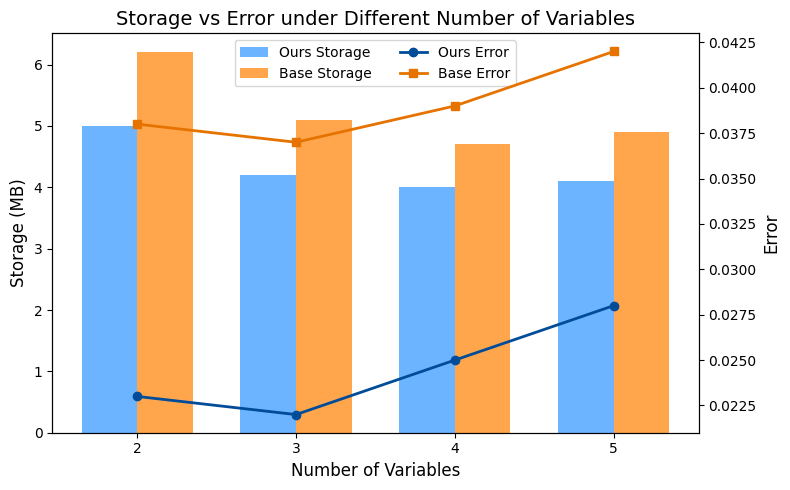

In [12]:
import matplotlib.pyplot as plt

# Example
variables = [2, 3, 4, 5]

storage_ours = [5.0, 4.2, 4.0, 4.1]
storage_base = [6.2, 5.1, 4.7, 4.9]

error_ours = [0.023, 0.022, 0.025, 0.028]
error_base = [0.038, 0.037, 0.039, 0.042]

fig, ax1 = plt.subplots(figsize=(8, 5))

# ---------------- Left Y-axis : Storage ----------------
bar_width = 0.35
x_idx = range(len(variables))

ax1.bar([i - bar_width/2 for i in x_idx], storage_ours, 
        width=bar_width, label="Ours Storage", color="#6cb4ff")
ax1.bar([i + bar_width/2 for i in x_idx], storage_base, 
        width=bar_width, label="Base Storage", color="#ffa64d")

ax1.set_ylabel("Storage (MB)", fontsize=12)
ax1.set_xlabel("Number of Variables", fontsize=12)
ax1.set_xticks(x_idx)
ax1.set_xticklabels(variables)

# ---------------- Right Y-axis : Error ----------------
ax2 = ax1.twinx()

ax2.plot(x_idx, error_ours, marker='o', linewidth=2, 
         color="#004c99", label="Ours Error")
ax2.plot(x_idx, error_base, marker='s', linewidth=2, 
         color="#e67300", label="Base Error")

ax2.set_ylabel("Error", fontsize=12)

# ---------------- Legends from both axes ----------------
lines_labels = ax1.get_legend_handles_labels()
lines_labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines_labels[0] + lines_labels2[0], 
           lines_labels[1] + lines_labels2[1], 
           loc="upper center", ncol=2)

plt.title("Storage vs Error under Different Number of Variables", fontsize=14)
plt.tight_layout()
plt.show()
